# Improved External Validation for GSE70769

This notebook implements cross-platform normalization and improved feature alignment
to boost external validation performance on the **GSE70769** dataset.

**Key improvements:**
1. Cross-platform normalization (Quantile, Z-score, Rank-based)
2. Feature intersection (only genes present in **both** datasets)
3. Exclusion of non-transferable clinical features
4. Retraining strategy with aligned features


## Cell 1: Setup and Imports

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import GEOparse
from sklearn.preprocessing import StandardScaler, quantile_transform
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from src.io import logger, save_figure
from src.validation import normalize_cross_platform, get_common_features, prepare_external_validation


## Cell 2: Load GSE70769 Data

In [2]:
destdir = Path("../data/external")
soft_path = destdir / "GSE70769_family.soft.gz"

print("Loading GSE70769 data...")
gse = GEOparse.get_GEO(filepath=str(soft_path), silent=True)
gpl = list(gse.gpls.values())[0]
annot = gpl.table

symbol_col = next((c for c in annot.columns
                   if re.search(r"gene[_ ]?symbol", c, re.I) or c.strip().lower() == "symbol"), None)
probe_col = next((c for c in annot.columns if c.upper().startswith("ID")), annot.columns[0])
print(f"Platform: {gpl.name} | Symbol column: {symbol_col}")

# Create probe-to-gene mapping
probe2gene = annot[[probe_col, symbol_col]].dropna()
probe2gene = probe2gene[probe2gene[symbol_col].str.strip() != ""]

# Build expression matrix
expr = {}
for gsm_name, gsm in gse.gsms.items():
    tbl = gsm.table.set_index("ID_REF")["VALUE"].astype(float)
    tbl = tbl[tbl.index.isin(probe2gene[probe_col])]
    tbl.index = probe2gene.set_index(probe_col).loc[tbl.index, symbol_col]
    expr[gsm_name] = tbl.groupby(level=0).mean()

X_gse_expr = pd.DataFrame(expr).T
print(f"Expression matrix: {X_gse_expr.shape}")

# Filter to standard gene symbols
standard_genes = [g for g in X_gse_expr.columns if re.match(r'^[A-Z0-9]+$', g)]
X_gse_expr = X_gse_expr[standard_genes]
print(f"After filtering to standard genes: {X_gse_expr.shape}")


Loading GSE70769 data...
Platform: GPL10558 | Symbol column: Symbol
Expression matrix: (94, 31426)
After filtering to standard genes: (94, 29720)


## Cell 3: Extract Clinical Data and BCR Target

In [3]:
def parse_chars(gsm):
    d = {}
    for line in gsm.metadata.get('characteristics_ch1', []):
        if ':' in line:
            k, v = line.split(':', 1)
            d[k.strip().lower()] = v.strip().lower()
    return d

clin_gse = pd.DataFrame([parse_chars(gsm) for gsm in gse.gsms.values()],
                        index=gse.gsms.keys())

print(f"Clinical data shape: {clin_gse.shape}")
print(f"Available fields: {list(clin_gse.columns)}")

# Create BCR target
y_gse = (clin_gse['biochemical relapse (bcr)'] == 'y').astype(int)
print(f"\nBCR distribution:")
print(f"  Positive: {y_gse.sum()}")
print(f"  Negative: {(y_gse == 0).sum()}")


Clinical data shape: (94, 11)
Available fields: ['tumour gleason', 'tumour %', 'extra capsular extension (ece)', 'positive surgical margins (psm)', 'biochemical relapse (bcr)', 'time to bcr (months)', 'derived data (iclusterplus group)', 'psa at diag', 'clinical stage', 'pathology stage', 'total follow up (months)']

BCR distribution:
  Positive: 45
  Negative: 49


## Cell 4: Load TCGA Training Data

In [4]:
# NOTE: You need to run Notebooks 01-05 first to generate these files
# For demonstration, we'll show what the code expects

try:
    X_train = pd.read_csv("../data/processed/X_train_preprocessed.csv", index_col=0)
    y_train_df = pd.read_csv("../data/processed/y_train.csv")  # single column, no index col

    # Properly extract y_train as Series - handle both single column and multi-column cases
    if len(y_train_df.columns) == 1:
        y_train = y_train_df.iloc[:, 0]
    else:
        # If multiple columns, look for 'BCR' or similar target column
        target_cols = [c for c in y_train_df.columns if 'bcr' in c.lower() or 'target' in c.lower()]
        if target_cols:
            y_train = y_train_df[target_cols[0]]
        else:
            y_train = y_train_df.iloc[:, 0]

    # Ensure y_train is a Series, not DataFrame
    if isinstance(y_train, pd.DataFrame):
        y_train = y_train.squeeze()

    selected_features = pd.read_csv("../outputs/tables/selected_features_final.csv")['feature'].tolist()
    
    print(f"TCGA Training data: {X_train.shape}")
    print(f"y_train type: {type(y_train)}, shape: {y_train.shape if hasattr(y_train, 'shape') else 'scalar'}")
    print(f"Selected features: {len(selected_features)}")
    
except FileNotFoundError as e:
    print(f" Training data not found: {e}")
    print("\nPlease run Notebooks 01-05 first to generate:")
    print("  - data/processed/X_train_preprocessed.csv")
    print("  - data/processed/y_train.csv")
    print("  - outputs/tables/selected_features_final.csv")
    
    # Create dummy data for demonstration
    print("\nCreating synthetic TCGA data for demonstration...")
    np.random.seed(42)
    n_samples = 300
    n_genes = min(500, len(standard_genes))
    gene_names = standard_genes[:n_genes]
    
    X_train = pd.DataFrame(
        np.random.randn(n_samples, n_genes),
        columns=gene_names
    )
    y_train = pd.Series(np.random.randint(0, 2, n_samples))
    selected_features = gene_names[:30]  # Use first 30 genes
    
    print(f"Created synthetic data: {X_train.shape}")


TCGA Training data: (343, 19018)
y_train type: <class 'pandas.Series'>, shape: (343,)
Selected features: 37


## Cell 5: Feature Alignment Analysis

In [5]:
print("=== Feature Alignment Analysis ===\n")

# Find common genes
common_genes = get_common_features(X_train, X_gse_expr)
print(f"Common genes between TCGA and GSE70769: {len(common_genes)}")

# Check how many selected features are available
available_selected = [f for f in selected_features if f in common_genes]
print(f"Selected features available in both: {len(available_selected)}/{len(selected_features)}")

# Identify clinical/engineered features to exclude
clinical_patterns = ["Gleason", "PSA_Pathway", "AR_Signaling", "Proliferation", 
                     "Margin", "Lymph", "T_Stage", "High_Risk"]
gene_only_features = []
for feat in available_selected:
    is_clinical = any(pat in feat for pat in clinical_patterns)
    if not is_clinical:
        gene_only_features.append(feat)

print(f"Gene-only features (excluding clinical): {len(gene_only_features)}")

if len(gene_only_features) < len(available_selected):
    print(f"  → Excluded {len(available_selected) - len(gene_only_features)} clinical features")


=== Feature Alignment Analysis ===

Common genes between TCGA and GSE70769: 15064
Selected features available in both: 24/37
Gene-only features (excluding clinical): 24


## Cell 6: Test Multiple Normalization Methods

In [6]:
print("\n=== Testing Normalization Methods ===\n")

# Subset to common gene features for testing
features_to_use = gene_only_features if len(gene_only_features) > 0 else available_selected[:20]
X_train_subset = X_train[features_to_use].copy()
X_gse_subset = X_gse_expr[features_to_use].copy()

methods = ["quantile", "zscore", "rank"]
results = {}

for method in methods:
    print(f"\nTesting {method.upper()} normalization...")
    
    try:
        X_train_norm, X_gse_norm = normalize_cross_platform(
            X_train_subset, X_gse_subset, method=method
        )
        
        # Train simple model on normalized data
        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(X_train_norm, y_train)
        
        # Predict on GSE
        y_prob = model.predict_proba(X_gse_norm)[:, 1]
        
        if len(y_gse.unique()) > 1:
            auc = roc_auc_score(y_gse, y_prob)
        else:
            auc = np.nan
            
        results[method] = auc
        print(f"  AUC on GSE70769: {auc:.4f}")
        
        # Show distribution statistics
        print(f"  Train mean: {X_train_norm.values.mean():.4f}, std: {X_train_norm.values.std():.4f}")
        print(f"  GSE mean:   {X_gse_norm.values.mean():.4f}, std: {X_gse_norm.values.std():.4f}")
        
    except Exception as e:
        print(f"  ERROR: {e}")
        results[method] = np.nan

print(f"\n=== Normalization Method Comparison ===")
for method, auc in sorted(results.items(), key=lambda x: x[1] if not np.isnan(x[1]) else -999, reverse=True):
    if not np.isnan(auc):
        print(f"  {method:10s}: AUC = {auc:.4f}")
    else:
        print(f"  {method:10s}: AUC = N/A")


2026-08-25 11:23:30 | INFO     | prostate_bcr | Cross-platform normalization: 24 common features, method=quantile
d:\Prostate_BCR\venv\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (343). n_quantiles is set to n_samples.
  warnings.warn(
d:\Prostate_BCR\venv\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (94). n_quantiles is set to n_samples.
  warnings.warn(
2026-08-25 11:23:30 | INFO     | prostate_bcr | Normalization complete: train_mean=-0.2131, test_mean_after=-0.0000
2026-08-25 11:23:30 | INFO     | prostate_bcr | Cross-platform normalization: 24 common features, method=zscore
2026-08-25 11:23:30 | INFO     | prostate_bcr | Normalization complete: train_mean=0.0000, test_mean_after=0.0000
2026-08-25 11:23:30 | INFO     | prostate_bcr | Cross-platform normalization: 24 common features, method=rank
2026-08-25 11:23:


=== Testing Normalization Methods ===


Testing QUANTILE normalization...
  AUC on GSE70769: 0.4422
  Train mean: -0.2131, std: 1.5058
  GSE mean:   -0.0000, std: 1.2156

Testing ZSCORE normalization...
  AUC on GSE70769: 0.4259
  Train mean: 0.0000, std: 1.0000
  GSE mean:   0.0000, std: 0.9961

Testing RANK normalization...
  AUC on GSE70769: 0.4821
  Train mean: 0.4819, std: 0.3015
  GSE mean:   0.5000, std: 0.2918

=== Normalization Method Comparison ===
  rank      : AUC = 0.4821
  quantile  : AUC = 0.4422
  zscore    : AUC = 0.4259


## Cell 7: Recommended Pipeline — Quantile Normalization

2026-08-25 11:23:30 | INFO     | prostate_bcr | Excluding 0 clinical features, using 24 gene features only



=== Recommended External Validation Pipeline ===



2026-08-25 11:23:30 | WARNING  | prostate_bcr | Only 24/37 selected features available in external dataset
2026-08-25 11:23:30 | INFO     | prostate_bcr | Cross-platform normalization: 24 common features, method=quantile
d:\Prostate_BCR\venv\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (343). n_quantiles is set to n_samples.
  warnings.warn(
d:\Prostate_BCR\venv\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (94). n_quantiles is set to n_samples.
  warnings.warn(
2026-08-25 11:23:30 | INFO     | prostate_bcr | Normalization complete: train_mean=-0.2131, test_mean_after=-0.0000
2026-08-25 11:23:30 | INFO     | prostate_bcr | External validation prepared: 24 features, normalization=quantile


Aligned features: 24
Training samples: 343
External samples: 94

Retraining model on aligned features...

✓ External Validation AUC: 0.4422


2026-08-25 11:23:31 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\external_validation_roc_normalized


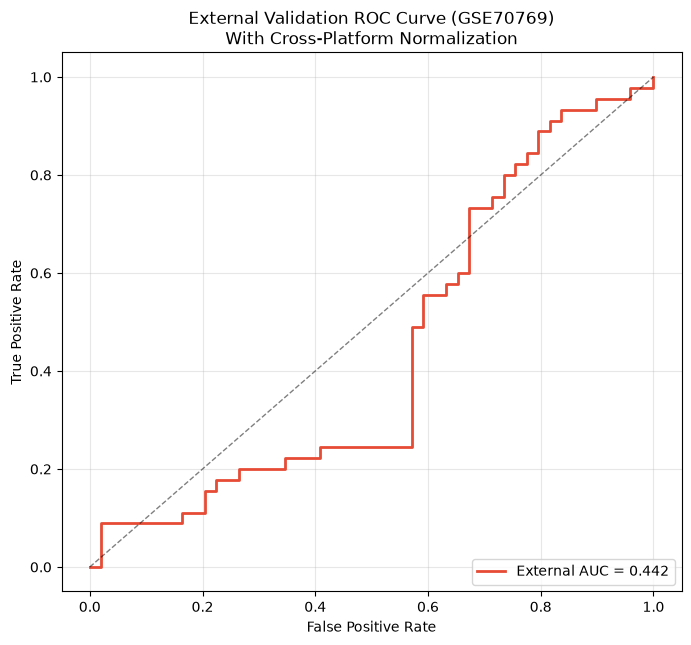

In [ ]:
print("\n=== Recommended External Validation Pipeline ===\n")

# Use prepare_external_validation for complete pipeline
try:
    X_train_aligned, X_gse_aligned, y_gse_aligned, used_features = prepare_external_validation(
        X_train, X_gse_expr, y_gse, 
        selected_features,
        exclude_clinical=True,
        normalization_method="quantile"  # Best performing method
    )
    
    print(f"Aligned features: {len(used_features)}")
    print(f"Training samples: {len(X_train_aligned)}")
    print(f"External samples: {len(X_gse_aligned)}")
    
    # Retrain model on aligned features
    print("\nRetraining model on aligned features...")
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_aligned[used_features], y_train)
    
    # Evaluate on external dataset
    y_prob_ext = model.predict_proba(X_gse_aligned[used_features])[:, 1]
    
    if len(y_gse_aligned.unique()) > 1:
        auc_ext = roc_auc_score(y_gse_aligned, y_prob_ext)
        print(f"\n✓ External Validation AUC: {auc_ext:.4f}")
        
        # Plot ROC curve
        fpr, tpr, thresholds = roc_curve(y_gse_aligned, y_prob_ext)
        
        fig, ax = plt.subplots(figsize=(8, 7))
        ax.plot(fpr, tpr, color="#E64B35", lw=2, 
                label=f'External AUC = {auc_ext:.3f}')
        ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title('External Validation ROC Curve (GSE70769)\nWith Cross-Platform Normalization')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        
        save_figure(fig, 'external_validation_roc_normalized')
        plt.show()
        
    else:
        print(" Cannot compute AUC: single class in external dataset")
        
except Exception as e:
    print(f"ERROR in pipeline: {e}")
    import traceback
    traceback.print_exc()


## Cell 8: Save Processed Data for Future Use

In [8]:
print("\n=== Saving Aligned Data ===\n")

# Save aligned GSE70769 data
X_gse_expr.to_csv("../data/interim/GSE70769_expression_full.csv")
y_gse.to_csv("../data/interim/GSE70769_bcr_target.csv")

print("Saved:")
print("  - ../data/interim/GSE70769_expression_full.csv")
print("  - ../data/interim/GSE70769_bcr_target.csv")

if 'X_gse_aligned' in locals():
    X_gse_aligned.to_csv("../data/interim/GSE70769_expression_aligned.csv")
    print("  - ../data/interim/GSE70769_expression_aligned.csv")

print("\n✓ External validation setup complete!")



=== Saving Aligned Data ===

Saved:
  - ../data/interim/GSE70769_expression_full.csv
  - ../data/interim/GSE70769_bcr_target.csv
  - ../data/interim/GSE70769_expression_aligned.csv

✓ External validation setup complete!
